# Bipartite graph scratch

In [119]:
import numpy as np
import polars as pl
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import optuna
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data, HeteroData
import networkx as nx
from torch_geometric.utils import to_networkx
import torch
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATv2Conv
from sklearn.manifold import TSNE
import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from torch.utils.data import DataLoader
from torchvision import transforms

In [2]:
def visualize_graph(G, color):
    plt.figure(figsize=(7,7))
    plt.xticks([])
    plt.yticks([])
    nx.draw_networkx(G, pos=nx.spring_layout(G, seed=42), with_labels=False,
                     node_color=color, cmap="Set2")
    plt.show()

def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

In [3]:
rna = pl.read_csv("xena_brca_data/TCGA.BRCA.sampleMap_HiSeqV2", separator="\t")

In [4]:
gene_names = rna[:,0]
rna = rna.drop("sample")

In [5]:
# load labels

clinicalMatrix = pl.read_csv("xena_brca_data/TCGA.BRCA.sampleMap_BRCA_clinicalMatrix", separator="\t", infer_schema_length=0)

cM = clinicalMatrix.filter(pl.col("PAM50_mRNA_nature2012") != "null")
cM


sampleID,AJCC_Stage_nature2012,Age_at_Initial_Pathologic_Diagnosis_nature2012,CN_Clusters_nature2012,Converted_Stage_nature2012,Days_to_Date_of_Last_Contact_nature2012,Days_to_date_of_Death_nature2012,ER_Status_nature2012,Gender_nature2012,HER2_Final_Status_nature2012,Integrated_Clusters_no_exp__nature2012,Integrated_Clusters_unsup_exp__nature2012,Integrated_Clusters_with_PAM50__nature2012,Metastasis_Coded_nature2012,Metastasis_nature2012,Node_Coded_nature2012,Node_nature2012,OS_Time_nature2012,OS_event_nature2012,PAM50Call_RNAseq,PAM50_mRNA_nature2012,PR_Status_nature2012,RPPA_Clusters_nature2012,SigClust_Intrinsic_mRNA_nature2012,SigClust_Unsupervised_mRNA_nature2012,Survival_Data_Form_nature2012,Tumor_T1_Coded_nature2012,Tumor_nature2012,Vital_Status_nature2012,_INTEGRATION,_PANCAN_CNA_PANCAN_K8,_PANCAN_Cluster_Cluster_PANCAN,_PANCAN_DNAMethyl_BRCA,_PANCAN_DNAMethyl_PANCAN,_PANCAN_RPPA_PANCAN_K8,_PANCAN_UNC_RNAseq_PANCAN_K16,_PANCAN_miRNA_PANCAN,…,progesterone_receptor_level_cell_percent_category,project_code,radiation_therapy,sample_type,sample_type_id,surgical_procedure_purpose_other_text,system_version,targeted_molecular_therapy,tissue_prospective_collection_indicator,tissue_retrospective_collection_indicator,tissue_source_site,tumor_tissue_site,vial_number,vital_status,year_of_initial_pathologic_diagnosis,_GENOMIC_ID_TCGA_BRCA_exp_HiSeqV2_exon,_GENOMIC_ID_TCGA_BRCA_exp_HiSeqV2_PANCAN,_GENOMIC_ID_TCGA_BRCA_RPPA_RBN,_GENOMIC_ID_TCGA_BRCA_mutation,_GENOMIC_ID_TCGA_BRCA_PDMRNAseq,_GENOMIC_ID_TCGA_BRCA_hMethyl450,_GENOMIC_ID_TCGA_BRCA_RPPA,_GENOMIC_ID_TCGA_BRCA_PDMRNAseqCNV,_GENOMIC_ID_TCGA_BRCA_mutation_curated_wustl_gene,_GENOMIC_ID_TCGA_BRCA_hMethyl27,_GENOMIC_ID_TCGA_BRCA_PDMarrayCNV,_GENOMIC_ID_TCGA_BRCA_miRNA_HiSeq,_GENOMIC_ID_TCGA_BRCA_mutation_wustl_gene,_GENOMIC_ID_TCGA_BRCA_miRNA_GA,_GENOMIC_ID_TCGA_BRCA_exp_HiSeqV2_percentile,_GENOMIC_ID_data/public/TCGA/BRCA/miRNA_GA_gene,_GENOMIC_ID_TCGA_BRCA_gistic2thd,_GENOMIC_ID_data/public/TCGA/BRCA/miRNA_HiSeq_gene,_GENOMIC_ID_TCGA_BRCA_G4502A_07_3,_GENOMIC_ID_TCGA_BRCA_exp_HiSeqV2,_GENOMIC_ID_TCGA_BRCA_gistic2,_GENOMIC_ID_TCGA_BRCA_PDMarray
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""TCGA-A1-A0SD-0…","""Stage IIA""","""59""","""2""","""Stage IIA""","""437""",null,"""Positive""","""FEMALE""","""Negative""",null,null,null,"""Negative""","""M0""","""Negative""","""N0""","""437""","""0""","""LumA""","""Luminal A""","""Positive""",null,"""-9""","""-3""","""enrollment""","""T_Other""","""T2""","""LIVING""","""TCGA-A1-A0SD-0…","""High""","""C3-BRCA/Lumina…","""cluster 1""","""BRCA non-CIMP …",null,"""BRCA nonbasal-…","""miRNA cluster …",…,"""90-99%""",null,null,"""Primary Tumor""","""01""",null,"""6th""",null,"""NO""","""YES""","""A1""","""Breast""","""A""","""LIVING""","""2005""","""15bad71d-3031-…","""15bad71d-3031-…",null,"""TCGA-A1-A0SD-0…","""TCGA-A1-A0SD-0…",null,null,"""TCGA-A1-A0SD-0…","""TCGA-A1-A0SD-0…","""TCGA-A1-A0SD-0…","""TCGA-A1-A0SD-0…","""TCGA-A1-A0SD-0…","""TCGA-A1-A0SD-0…",null,"""15bad71d-3031-…",null,"""TCGA-A1-A0SD-0…","""TCGA-A1-A0SD-0…","""TCGA-A1-A0SD-0…","""15bad71d-3031-…","""TCGA-A1-A0SD-0…","""TCGA-A1-A0SD-0…"
"""TCGA-A1-A0SE-0…","""Stage I""","""56""","""2""","""Stage I""","""1320""",null,"""Positive""","""FEMALE""","""Negative""",null,null,null,"""Negative""","""M0""","""Negative""","""N0""","""1320""","""0""","""LumA""","""Luminal A""","""Positive""",null,"""-5""","""-7""","""enrollment""","""T1""","""T1""","""LIVING""","""TCGA-A1-A0SE-0…","""Iq""","""C3-BRCA/Lumina…","""cluster 1""","""BRCA non-CIMP …",null,"""BRCA nonbasal-…","""miRNA cluster …",…,"""90-99%""",null,null,"""Primary Tumor""","""01""",null,"""6th""",null,"""NO""","""YES""","""A1""","""Breast""",null,"""LIVING""","""2005""","""a998

In [6]:
labels = cM.select(["sampleID","PAM50_mRNA_nature2012"])
labels = labels.filter(pl.col("PAM50_mRNA_nature2012") != "Normal-like")

In [7]:
y_all = labels["PAM50_mRNA_nature2012"].to_numpy()
y_all

array(['Luminal A', 'Luminal A', 'Luminal A', 'Luminal A', 'Basal-like',
       'Luminal B', 'Basal-like', 'Luminal A', 'Basal-like', 'Basal-like',
       'Luminal B', 'Basal-like', 'Basal-like', 'Luminal A',
       'HER2-enriched', 'HER2-enriched', 'Luminal A', 'HER2-enriched',
       'Basal-like', 'Luminal A', 'Luminal A', 'Luminal A', 'Luminal B',
       'Luminal A', 'Luminal A', 'Luminal B', 'HER2-enriched',
       'HER2-enriched', 'Luminal A', 'Basal-like', 'HER2-enriched',
       'Basal-like', 'Luminal A', 'Luminal B', 'Luminal A', 'Luminal A',
       'Luminal A', 'HER2-enriched', 'Luminal B', 'Luminal A',
       'Luminal A', 'Luminal A', 'Luminal A', 'Luminal A', 'Luminal A',
       'Luminal B', 'Basal-like', 'Luminal A', 'Luminal B', 'Luminal B',
       'Basal-like', 'Luminal A', 'Basal-like', 'HER2-enriched',
       'Basal-like', 'Luminal B', 'Luminal B', 'Luminal A', 'Luminal A',
       'Luminal A', 'Luminal A', 'Luminal A', 'Basal-like', 'Luminal A',
       'Luminal B', 'Lum

In [8]:
# display label counts
np.unique(labels["PAM50_mRNA_nature2012"].to_numpy(), return_counts=True)

(array(['Basal-like', 'HER2-enriched', 'Luminal A', 'Luminal B'],
       dtype=object),
 array([ 98,  58, 231, 127]))

In [9]:
rna = rna.select(labels["sampleID"].to_numpy())

In [10]:
rna

TCGA-A1-A0SD-01,TCGA-A1-A0SE-01,TCGA-A1-A0SH-01,TCGA-A1-A0SJ-01,TCGA-A1-A0SK-01,TCGA-A1-A0SM-01,TCGA-A1-A0SO-01,TCGA-A2-A04N-01,TCGA-A2-A04P-01,TCGA-A2-A04Q-01,TCGA-A2-A04R-01,TCGA-A2-A04T-01,TCGA-A2-A04U-01,TCGA-A2-A04V-01,TCGA-A2-A04W-01,TCGA-A2-A04X-01,TCGA-A2-A04Y-01,TCGA-A2-A0CL-01,TCGA-A2-A0CM-01,TCGA-A2-A0CP-01,TCGA-A2-A0CQ-01,TCGA-A2-A0CS-01,TCGA-A2-A0CT-01,TCGA-A2-A0CU-01,TCGA-A2-A0CV-01,TCGA-A2-A0CW-01,TCGA-A2-A0CX-01,TCGA-A2-A0CY-01,TCGA-A2-A0CZ-01,TCGA-A2-A0D0-01,TCGA-A2-A0D1-01,TCGA-A2-A0D2-01,TCGA-A2-A0D3-01,TCGA-A2-A0D4-01,TCGA-A2-A0EM-01,TCGA-A2-A0EN-01,TCGA-A2-A0EO-01,…,TCGA-E2-A14W-01,TCGA-E2-A14X-01,TCGA-E2-A14Y-01,TCGA-E2-A14Z-01,TCGA-E2-A150-01,TCGA-E2-A152-01,TCGA-E2-A153-01,TCGA-E2-A154-01,TCGA-E2-A155-01,TCGA-E2-A156-01,TCGA-E2-A158-01,TCGA-E2-A159-01,TCGA-E2-A15A-01,TCGA-E2-A15C-01,TCGA-E2-A15D-01,TCGA-E2-A15E-01,TCGA-E2-A15F-01,TCGA-E2-A15G-01,TCGA-E2-A15H-01,TCGA-E2-A15I-01,TCGA-E2-A15J-01,TCGA-E2-A15K-01,TCGA-E2-A15L-01,TCGA-E2-A15M-01,TCGA-E2-A15O-01,TCGA-E2-A15P-01,TCGA-E2-A15R-01,TCGA-E2-A15S-01,TCGA-E2-A15T-01,TCGA-E2-A1AZ-01,TCGA-E2-A1B0-01,TCGA-E2-A1B1-01,TCGA-E2-A1B4-01,TCGA-E2-A1B5-01,TCGA-E2-A1B6-01,TCGA-E2-A1BC-01,TCGA-E2-A1BD-01
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
9.1657,9.7179,8.8669,9.7663,9.8632,8.8234,8.6701,9.9831,10.5102,10.064,9.5425,10.449,9.4763,10.5333,8.9774,8.9665,9.3774,9.5693,11.4132,9.6413,10.3112,9.2703,9.0876,11.2247,8.9437,9.741,8.9323,8.4062,10.1639,8.3209,11.1395,10.1611,9.2467,10.9353,9.3572,10.0545,9.778,…,8.9611,10.7636,9.9899,9.8046,11.2344,9.8236,9.984,9.2405,9.8415,10.3731,9.2199,10.1219,9.1705,10.0851,9.2262,9.7065,10.0334,10.0949,9.4848,9.1406,9.2531,9.9412,9.3713,8.453,9.376,9.1228,9.1934,10.0346,9.8209,9.1036,8.5746,9.3223,10.4367,8.9027,8.6965,9.0303,10.7991
2.4935,3.3983,1.6631,6.1765,7.497,1.8177,8.9699,1.7558,6.9166,2.2799,1.4911,9.2573,6.3214,2.9105,2.5516,1.6612,3.6294,3.6849,0.0,4.8982,0.4407,2.3655,1.1726,2.9769,3.0291,3.35,0.8538,5.0676,4.063,1.7954,1.9355,2.1132,0.0,4.0158,1.4728,4.2849,2.5901,…,1.7638,4.8435,2.8783,2.9498,2.9782,2.3097,1.6892,1.9935,2.1329,0.7806,4.3358,4.1235,0.7135,0.848,3.8032,4.4089,0.8836,2.4616,1.1422,3.0117,0.4366,1.3397,1.6929,4.9786,0.8672,1.7922,0.3056,5.0409,0.3936,5.7418,1.3134,4.919,1.8654,4.8873,4.6748,6.9578,2.1772
0.0,0.0,0.4449,0.0,0.7051,1.178,0.0,0.0,0.6028,0.0,0.0,0.0,0.0,2.0906,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4891,0.6906,0.0,7.7299,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.8064,0.0,0.0,0.0,0.0,0.638,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0372,0.0,0.0,1.4776,0.0,0.8114
11.7868,11.3219,11.8779,11.502,12.099,11.9934,11.6209,12.185,12.1741,11.7065,11.9362,11.3839,12.5415,12.22,12.0188,12.5742,12.0841,11.6492,12.0196,12.0527,12.2531,12.3055,11.1702,11.5801,12.0265,12.2589,11.945,12.9661,11.6858,11.8358,13.0469,11.7749,11.9473,12.1437,11.6602,12.0735,11.881,…,12.3585,11.8525,11.7697,12.3889,11.3972,12.1153,11.7244,11.5464,11.9198,12.0953,11.8904,12.0105,12.2024,11.9198,11.9175,11.7502,12.0135,12.2843,12.3655,12.0196,11.9345,11.9704,11.88,11.7094,12.4611,12.4242,11.7385,12.4475,11.8324,11.416,11.7854,11.7005,12.428,12.6904,12.3403,11.8271,12.2783
11.0131,11.2617,11.8526,11.4405,9.9933,11.9332,11.0278,11.3242,11.2632,10.7574,10.4421,10.6897,10.9603,11.2698,11.9258,11.0061,10.9864,11.0977,11.1327,11.1117,11.1687,10.7255,11.4965,11.116,11.5781,10.6494,10.7706,10.4751,11.2883,10.838,11.5712,10.9105,12.0452,10.1117,11.7259,10.9669,11.3562,…,11.3929,11.1539,11.0064,10.2678,11.758,11.8669,11.1408,10.3065,11.696,11.6226,10.6569,12.1943,10.6067,11.4468,11.066,11.5324,10.837,11.112,10.7207,11.3718,10.688,10.898,11.183,11.415,10.718,10.5873,10.1383,10.8017,11.1716,11.2437,10.9101,11.6778,11.0804,11.

In [11]:
# filter low var rows
rna_mat = rna.to_numpy()
rna_vars = rna_mat.var(axis=1)
high_var_mask = rna_vars > 0.01

np.unique(high_var_mask, return_counts=True)

high_var_idx = np.where(high_var_mask)[0]

In [12]:
gene_names = gene_names[high_var_idx]
rna = rna[high_var_idx]

print(rna.shape, gene_names.shape)

(19767, 514) (19767,)


In [13]:
label_encoder = LabelEncoder()
label_encoder.fit(y_all)
y_all_e = label_encoder.transform(y_all)

# add numberd labels to labels df
labels = labels.with_columns(y=y_all_e)

In [14]:
# labels and rna columns are aligned, do train, val, test split

# random split for train / test
train_temp_idx, test_idx = train_test_split(
    np.arange(rna.shape[1]),
    test_size=0.3,
    # stratify=y,
    random_state=4
)

In [15]:
train_temp_idx

array([454, 337, 369, 153,  39, 195,  84, 473, 394,  34, 274, 503, 269,
       162, 472, 347, 317, 202, 427, 368, 395,  43,  42, 172, 354, 380,
        83, 424, 170, 105, 445, 140, 251, 497, 146, 289, 232, 482, 248,
       417,  96,   1, 275, 301, 312, 245, 191, 210, 409, 478,  60, 193,
        12, 238, 413, 361, 351, 214, 147, 485, 228, 128, 408, 173,  38,
       326, 213, 310, 403, 355,  93, 466, 400, 272, 376,  88, 339, 112,
       450, 499, 323, 460,  46, 268, 415, 104, 345, 130,  71, 498, 186,
        99, 256, 505, 280, 391, 378, 167, 113, 367, 374, 110, 137,  16,
       377, 300,  91, 101, 204, 448,  17,  20, 263, 382, 476, 493, 346,
        69, 223, 342, 341, 333, 278, 182, 477, 185, 465, 132, 304, 177,
       307, 438, 504,  19,  48, 334, 457, 411, 116, 365, 235, 285, 492,
       414, 246, 423, 111, 483, 332,  37, 118, 277, 233,  23, 258, 309,
        90,  28,  35, 455, 459, 501, 178,  81,  57, 432, 121,  26, 242,
       357,   4, 305,  77, 451, 283, 135, 318, 218, 386, 491, 46

In [16]:
train_idx, val_idx = train_test_split(
    train_temp_idx, 
    test_size=0.1, 
    stratify=y_all_e[train_temp_idx],                   
    random_state=4
)

In [17]:
# split dataframes
train_df = rna[:, train_idx.tolist()]
train_labels = labels[train_idx]
val_df = rna[:, val_idx.tolist()]
val_labels = labels[val_idx]
test_df = rna[:, test_idx.tolist()]
test_labels = labels[test_idx]

In [18]:
# select features based on the training set
num_labels = len(np.unique(y_all_e))
genes_class_mean = np.zeros((rna.shape[0], num_labels))

# separate training samples by class
for label in range(num_labels):
    # select cols which are from this class
    label_samples = train_labels.filter(pl.col("y") == label)["sampleID"].to_numpy()
    label_train_df = train_df[label_samples].to_numpy()

    genes_class_mean[:, label] = label_train_df.mean(axis=1)

In [19]:
genes_class_variance = genes_class_mean.var(axis=1)

class_var_order = np.argsort(genes_class_variance)

# select the 500 genes with the largest variance
best_500 = class_var_order >= (genes_class_variance.shape[0] - 500)
best_500_idx = np.where(best_500)[0]

# selection itself
train_df = train_df[best_500_idx]
val_df = val_df[best_500_idx]
test_df = test_df[best_500_idx]

In [20]:
X_train = train_df.to_numpy().T
y_train = train_labels["y"].to_numpy()
X_val = val_df.to_numpy().T
y_val = val_labels["y"].to_numpy()
X_test = test_df.to_numpy().T
y_test = test_labels["y"].to_numpy()

# scale everything
std_scale = StandardScaler().fit(X_train)
X_train = std_scale.transform(X_train) 
X_val = std_scale.transform(X_val)
X_test = std_scale.transform(X_test)

In [21]:
# eval using knns
ks = (1, 30)

# eval on rbf svms
def objective_knn(trial):

    knn = KNeighborsClassifier(
        n_neighbors=trial.suggest_int("n_neighbors", ks[0], ks[1]),
        weights=trial.suggest_categorical("weights", ["uniform", "distance"]),
    )


    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_val)

    f1 = f1_score(y_val, y_pred, average="weighted")

    return f1

study = optuna.create_study(direction="maximize")
study.optimize(objective_knn, n_trials=200)

# print the mean f1 score for the best performing parameter
# print(
#     f"| RBF SVM | {best_results['acc']:.4f} +/- {best_results['acc_std']:.4f} | {best_results['f1_macro']:.4f} +/- {best_results['f1_macro_std']:.4f} | {best_results['f1_weighted']:.4f} +/- {best_results['f1_weighted_std']:.4f} |"
# )
print(f"study {study.best_value=}, {study.best_params=}")

[I 2024-03-17 19:03:28,763] A new study created in memory with name: no-name-db58a9ce-6dcd-4bc3-968f-5a500b4dd7a1
[I 2024-03-17 19:03:28,794] Trial 0 finished with value: 0.6180555555555556 and parameters: {'n_neighbors': 26, 'weights': 'uniform'}. Best is trial 0 with value: 0.6180555555555556.
[I 2024-03-17 19:03:28,797] Trial 1 finished with value: 0.6196969696969696 and parameters: {'n_neighbors': 1, 'weights': 'distance'}. Best is trial 1 with value: 0.6196969696969696.
[I 2024-03-17 19:03:28,799] Trial 2 finished with value: 0.6180555555555556 and parameters: {'n_neighbors': 20, 'weights': 'uniform'}. Best is trial 1 with value: 0.6196969696969696.
[I 2024-03-17 19:03:28,802] Trial 3 finished with value: 0.5642857142857144 and parameters: {'n_neighbors': 29, 'weights': 'distance'}. Best is trial 1 with value: 0.6196969696969696.
[I 2024-03-17 19:03:28,805] Trial 4 finished with value: 0.5725548164572555 and parameters: {'n_neighbors': 25, 'weights': 'distance'}. Best is trial 1 w

study study.best_value=0.6700757575757577, study.best_params={'n_neighbors': 19, 'weights': 'uniform'}


In [22]:
knn = KNeighborsClassifier(
    n_neighbors=study.best_params["n_neighbors"],
    weights=study.best_params["weights"]
)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

f1 = f1_score(y_test, y_pred, average="weighted")

print("knn f1: ", f1)

knn f1:  0.5773005442009649


## KNNs
f1 score of ~0.53

In [23]:
C_range: tuple = (1e-3, 1e3)
gamma_range: tuple = (1e-3, 1e3)

# eval on rbf svms
def objective(trial):

    svm = SVC(
        C=trial.suggest_float("C", C_range[0], C_range[1], log=True),
        gamma=trial.suggest_float(
            "gamma", gamma_range[0], gamma_range[1], log=True
        ),
        class_weight=trial.suggest_categorical("class_weight", ["balanced", None]),
        kernel="rbf",
    )

    svm.fit(X_train, y_train)
    
    y_pred = svm.predict(X_val)

    f1 = f1_score(y_val, y_pred, average="weighted")

    return f1

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=200)

# print the mean f1 score for the best performing parameter
# print(
#     f"| RBF SVM | {best_results['acc']:.4f} +/- {best_results['acc_std']:.4f} | {best_results['f1_macro']:.4f} +/- {best_results['f1_macro_std']:.4f} | {best_results['f1_weighted']:.4f} +/- {best_results['f1_weighted_std']:.4f} |"
# )
print(f"study {study.best_value=}, {study.best_params=}")

[I 2024-03-17 19:03:31,212] A new study created in memory with name: no-name-db5869c2-bfc2-4298-9efb-99aa13cb50cd
[I 2024-03-17 19:03:31,258] Trial 0 finished with value: 0.2450980392156863 and parameters: {'C': 7.003442969876774, 'gamma': 50.73231448663766, 'class_weight': None}. Best is trial 0 with value: 0.2450980392156863.
[I 2024-03-17 19:03:31,286] Trial 1 finished with value: 0.2450980392156863 and parameters: {'C': 0.007146729613020268, 'gamma': 11.161241710490854, 'class_weight': None}. Best is trial 0 with value: 0.2450980392156863.
[I 2024-03-17 19:03:31,303] Trial 2 finished with value: 0.831578947368421 and parameters: {'C': 0.8753427488139695, 'gamma': 0.0030955793224214357, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.831578947368421.
[I 2024-03-17 19:03:31,322] Trial 3 finished with value: 0.2450980392156863 and parameters: {'C': 0.8430370849200552, 'gamma': 0.2092801742148403, 'class_weight': None}. Best is trial 2 with value: 0.831578947368421.
[I 2024-

study study.best_value=0.8586396546922862, study.best_params={'C': 0.8637531174577123, 'gamma': 0.002759924068960851, 'class_weight': 'balanced'}


In [24]:
# fit model with best params and test on test set
svm = SVC(
        C=study.best_params["C"],
        gamma=study.best_params["gamma"],
        class_weight=study.best_params["class_weight"],
        kernel="rbf",
)

svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

f1 = f1_score(y_test, y_pred, average="weighted")

print("svm f1: ", f1)

svm f1:  0.8386404647138795


## SVMs with rbf kernel
- weighted f1 score with ~0.8 on test set
- with normalization wf1 score ~0.83 on test set

In [25]:
X_train

array([[-0.32467966, -0.5365642 , -0.24281618, ...,  0.14543537,
         0.55069047, -0.56628668],
       [ 1.21747044,  0.30244801,  1.64738967, ..., -0.50223283,
         0.52021466,  0.37972033],
       [-1.23769213,  1.0759012 , -1.27576896, ..., -0.50223283,
         0.47757525, -0.60059781],
       ...,
       [ 0.68946323, -0.0486331 , -0.62310937, ...,  0.28751278,
         0.1102615 , -0.50561015],
       [-1.56929343,  0.39905503, -2.19272169, ..., -0.14679931,
         0.14608394, -0.36150338],
       [ 2.34871169,  0.16953873, -1.35352723, ..., -0.50223283,
        -0.27883979, -0.30443854]])

# Classical neural network

In [26]:
class MyDataset(torch.utils.data.Dataset):
  def __init__(self, X, y, transform=None):
    """
    This function initializes the MyDataset class.

    Args:
        X (np.ndarray): The features (data points).
        y (np.ndarray): The labels (target values).
        transform (torchvision.transforms, optional): A transform to apply to the data. Defaults to None.
    """
    self.X = X
    self.y = y
    self.transform = transform  # Optional transform

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    X_sample = self.X[idx]
    y_sample = self.y[idx]

    # Apply transform if provided
    if self.transform:
      X_sample = self.transform(X_sample)  # Convert to PyTorch tensor

    return X_sample, y_sample

X_train, X_val, X_test = torch.tensor(X_train), torch.tensor(X_val), torch.tensor(X_test)
y_train, y_val, y_test = torch.tensor(y_train), torch.tensor(y_val), torch.tensor(y_test)

# Convert data to torch.float32
X_train = X_train.float()
X_val = X_val.float()
X_test = X_test.float()

# Create datasets with transforms (assuming your data is suitable for ToTensor)
train_dataset = MyDataset(X_train, y_train)
val_dataset = MyDataset(X_val, y_val)
test_dataset = MyDataset(X_test, y_test)

batch_size = 32  # Adjust batch size based on your hardware and data size

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=11)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=11)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=11)

In [29]:
class MLP(torch.nn.Module):
    def __init__(self, input_sz, num_classes, hidden_channels):
        super().__init__()
        torch.manual_seed(12345)
        self.lin1 = Linear(input_sz, hidden_channels)
        self.lin2 = Linear(hidden_channels, num_classes)

    def forward(self, x):
        x = self.lin1(x)
        x = F.relu(x)  # Corrected this line
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin2(x)
        return x

class MLPTrainer(L.LightningModule):  # Fixed the import of LightningModule
    def __init__(self, net):  # Changed 'Net' to 'net'
        super().__init__()
        self.net = net  # Changed 'Net' to 'net'

    def training_step(self, batch, batch_idx):
        x, y = batch
        x = x.view(x.size(0), -1)
        y_pred = self.net(x)
        loss = F.cross_entropy(y_pred, y)  # Changed 'torch.nn.functional' to 'F'
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        x = x.view(x.size(0), -1)
        y_pred = self.net(x)
        val_loss = F.cross_entropy(y_pred, y)  # Changed 'torch.nn.functional' to 'F'
        val_f1 = f1_score(y, y_pred.argmax(dim=1), average='weighted')  # Fixed the calculation of f1_score
        self.log('val_loss', val_loss)
        self.log('val_f1', val_f1)

    def test_step(self, batch, batch_idx):
        x, y = batch
        x = x.view(x.size(0), -1)
        y_pred = self.net(x)
        test_f1 = f1_score(y, y_pred.argmax(dim=1), average='weighted')  # Fixed the calculation of f1_score
        self.log('test_f1', test_f1)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min')
        return {
            "optimizer": optimizer,
            "lr_scheduler_config": {
                "scheduler": scheduler,
                "monitor": "val_loss",
            }
        }
# Assuming X_train, X_val, X_test, y_train, y_val, y_test, train_loader, test_loader are already defined

# Create model instance
model = MLP(
    input_sz=X_train.shape[1],
    num_classes=len(np.unique(y_train)),
    hidden_channels=32
)

# Create LightningModule instance
mlp = MLPTrainer(model)

# Create PyTorch Lightning Trainer
trainer = L.Trainer(
    max_epochs=40,
    log_every_n_steps=1,
    callbacks=[EarlyStopping(monitor="val_loss", mode="min")],
)

# Train the model
trainer.fit(
    model=mlp,
    train_dataloaders=train_loader,  # Fixed the argument name
    val_dataloaders=val_loader  # Added validation data
)

# Test the model
trainer.test(
    model=mlp,
    dataloaders=test_loader  # Fixed the argument name
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/lubojjan/micromamba/envs/diploma/lib/python3.12/site-packages/lightning/pytorch/core/optimizer.py:376: Found unsupported keys in the optimizer configuration: {'lr_scheduler_config'}

  | Name | Type | Params
------------------------------
0 | net  | MLP  | 16.2 K
------------------------------
16.2 K    Trainable params
0         Non-trainable params
16.2 K    Total params
0.065     Total estimated model params size (MB)


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Testing: |                                                                                                    …

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         test_f1            0.8352653384208679
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_f1': 0.8352653384208679}]

## MLP results
so with a simple MLP we get about the same results as with rbf svm, ~
0.835

## Mogonet style gnn

In [169]:
def cosine_similarity_matrix(matrix):
    """
    given a matrix of (n_samples, n_features) compute the cosine similarities, between the samples
    """
    # Compute dot product between all pairs of vectors
    dot_products = np.dot(matrix, matrix.T)
    
    # Compute magnitudes of all vectors
    magnitudes = np.linalg.norm(matrix, axis=1)
    
    # Compute outer product of magnitudes to obtain matrix of magnitudes product
    magnitude_products = np.outer(magnitudes, magnitudes)
    
    # Compute cosine similarity matrix
    cosine_similarities = dot_products / magnitude_products
    
    return cosine_similarities

def keep_n_neighbours(A, n):
      rows, cols = A.shape
      for i in range(rows):
        # Find indices of the k highest elements
        bottom_k_indices = np.argsort(A[i])[:-n]
        # Set all other elements to zero
        A[i][bottom_k_indices] = 0
      return A
    

def dense_to_coo(adj_mat):
    """
    convert an adjacency matrix in a dense format to a torch tensor in COO format
    """
    indices = np.where(adj_mat != 0)
    indices = np.vstack((indices[0], indices[1]))
    return torch.tensor(indices, dtype=torch.int64)

In [63]:
from torch_geometric.nn import GCNConv


class GCN(torch.nn.Module):
    def __init__(self, input_sz, n_classes, hidden_channels):
        super().__init__()
        torch.manual_seed(1234567)
        self.conv1 = GCNConv(input_sz, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, n_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv2(x, edge_index)
        return x

class GAT(torch.nn.Module):
    def __init__(self, input_sz, n_classes, hidden_channels, heads):
        super().__init__()
        torch.manual_seed(1234567)
        self.conv1 = GATv2Conv(input_sz, hidden_channels, heads, dropout=0.6)
        self.conv2 = GATv2Conv(hidden_channels * heads, n_classes, heads=1, concat=False, dropout=0.6)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.4, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.4, training=self.training)
        x= self.conv2(x, edge_index)
        return x

In [132]:
# build mogonet style GNN with
# a. thresholded cosine similarity

# transform features to (n_samples, n_features) tensor
X = rna.to_numpy().T
X = X[:, best_500_idx]


# construct adjacency matrix
eps = 0.985
n = 15
A = cosine_similarity_matrix(X)
A = keep_n_neighbours(A, n)
# A[np.abs(A) < eps] = 0

X = std_scale.transform(X)
X = torch.tensor(X, dtype=torch.float32)
print(X.shape)

# construct edge indices
edge_indices = dense_to_coo(A)
print(edge_indices.shape)

# construct training mask
train_mask = np.zeros(X.shape[0], dtype=bool)
train_mask[train_idx] = True
train_mask = torch.tensor(train_mask)

val_mask = np.zeros(X.shape[0], dtype=bool)
val_mask[val_idx] = True
val_mask = torch.tensor(val_mask)

test_mask = np.zeros(X.shape[0], dtype=bool)
test_mask[test_idx] = True
test_mask = torch.tensor(test_mask)

y = torch.tensor(y_all_e, dtype=torch.int64)

data = Data(
    x=X,
    edge_index=edge_indices,
    y=y,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask,
)

torch.Size([514, 500])
torch.Size([2, 7710])


In [133]:
print(f"num of isolated nodees {np.sum(A.sum(axis=1) == 1)}")

num of isolated nodees 0


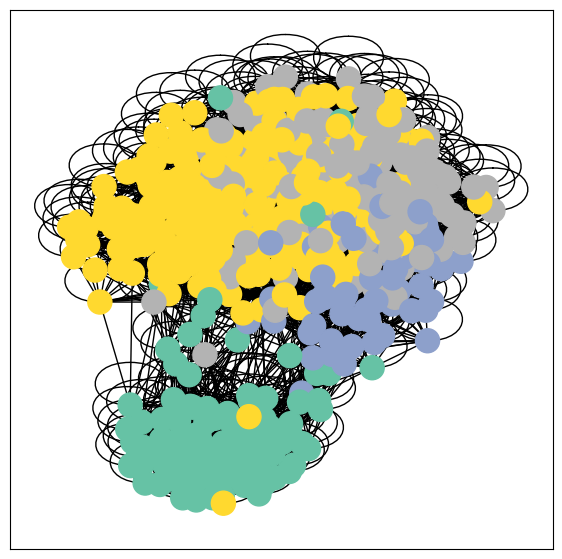

In [134]:
G = to_networkx(data, to_undirected=True)
visualize_graph(G, color=data.y)

In [135]:
# model = GCN(
#     input_sz=X_train.shape[1],
#     n_classes=len(np.unique(y_train)),
#     hidden_channels=32,
# )
model = GAT(
    input_sz=X_train.shape[1],
    n_classes=len(np.unique(y_train)),
    hidden_channels=64,
    heads=4,
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.25)  # Define the learning rate scheduler

def train():
    model.train()
    optimizer.zero_grad()  # Clear gradients.
    out = model(data.x, data.edge_index)  # Perform a single forward pass.
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    return loss

def test(mask):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)  # Use the class with highest probability.
    test_correct = pred[mask] == data.y[mask]  # Check against ground-truth labels.
    test_f1 = f1_score(pred[mask], data.y[mask], average="weighted")
    test_acc = int(test_correct.sum()) / int(mask.sum())  # Derive ratio of correct predictions.
    return test_acc, test_f1

best_val_f1 = 0

for epoch in range(1, 201):
    loss = train()
    val_loss = test(data.val_mask)
    if epoch % 50 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f} Val acc {val_loss[0]:.4f} Val f1 {val_loss[1]:.4f}')
    # scheduler.step()  # Step the learning rate scheduler

test_acc = test(data.test_mask)
print(f'Test Accuracy: {test_acc[0]:.4f}, test f1: {test_acc[1]:.4f}')

Epoch: 050, Loss: 0.9417 Val acc 0.8333 Val f1 0.8391
Epoch: 100, Loss: 0.7812 Val acc 0.8333 Val f1 0.8414
Epoch: 150, Loss: 0.7141 Val acc 0.8333 Val f1 0.8414
Epoch: 200, Loss: 0.6761 Val acc 0.8333 Val f1 0.8414
Test Accuracy: 0.8065, test f1: 0.8153


## gnn results
- mogonet style with gcn gets ~0.77
- mogonet style with gat gets around 0.8-0.85, depends on params and the graph it gets initialized with, so about the same as rbf svms and mlp
- interestingly on regular gcn the thresholded cosine similarity graph works much better than keep n most similar neighbours one even though the graph is a lot more disconnected, with GATs we get about the same performance with both graphs
- the parameters could be tuned with optuna

In [ ]:
# b. moglam style cosine similarity + learned graph

In [ ]:
# c. GAT layers

In [ ]:
# d. GAT layers + moglam style learned graph

In [136]:
# build bipartite graph style GNN

# determine the expression of gene accross the population
# - if the gene is overexpressed for that sample connect with 1
# - if the gene is underexpressed connect with -1
# - else connect with 0
# the over/under expression cutoff is a parameter we will have to tune
# GATv2Conv can use edge attribute vectors, so we can place these into the vectors
# RGAT conv can also use these

# transform features to (n_samples, n_features) tensor
X = rna.to_numpy().T
X = X[:, best_500_idx]
Xn = std_scale.transform(X)
Xt = torch.tensor(X, dtype=torch.float32)
print(X.shape)

(514, 500)


In [171]:
A = np.random.randint(low=0,high=10,size=(5,3))
print(A)
A_exps = create_expression_connections(A)
A_exps

[[5 4 2]
 [8 2 7]
 [4 1 1]
 [3 8 0]
 [4 5 0]]


array([[ 0,  0,  0],
       [ 1,  0,  1],
       [ 0, -1,  0],
       [-1,  1,  0],
       [ 0,  0,  0]])

In [170]:
A

array([[8, 7, 4],
       [1, 7, 2],
       [0, 7, 2],
       [2, 0, 6],
       [6, 0, 4]])

In [173]:
dense_to_coo(A_exps)

tensor([[1, 1, 2, 3, 3],
        [0, 2, 1, 0, 1]])

In [161]:
def create_expression_connections(X, std_multiplier=1.0):
    """
    This function identifies and categorizes gene expression levels as 
    under-expressed (-1), over-expressed (1), or baseline (0) based on standard 
    deviation from the mean.
    
    Args:
     X (np.ndarray): A 2D NumPy array representing gene expression data, 
         with shape (samples, genes).
     std_multiplier (float, optional): A hyperparameter that scales the 
         standard deviation to define the expression bounds. Defaults to 1.0.
    
    Returns:
     np.ndarray: A 2D NumPy array with the same shape as X, where each element 
         indicates the expression category (-1, 0, or 1) for the corresponding 
         gene in each sample.
    """
    mean_exps = X.mean(axis=0)
    exps_std = X.std(axis=0)
    
    lb_exps = mean_exps - exps_std * std_multiplier
    ub_exps = mean_exps + exps_std * std_multiplier
    
    A_exps = np.zeros_like(X)

    mask_below = X <= lb_exps
    mask_above = X >= ub_exps
    
    A_exps[mask_below] = -1  # Set under-expressed elements
    A_exps[mask_above] = 1  # Set over-expressed elements

    return A_exps

In [166]:
A_exps = create_expression_connections(X)

In [118]:


# construct A (n_samples+n_features, n_samples+n_features), where
# - nodes (0, X.shape[0]) are sample nodes
# - nodes (X.shape[0],X.shape[0]+X.shape[1]) are feature nodes
A = torch.eye(X.shape[0], X.shape[1])
A_samples = torch.eye(X.shape[0])

bipartite_data

(array([10.40268759, -0.34958172,  8.55472789,  8.43211476,  2.64797305,
         0.1312876 , -0.1530164 ,  0.77254762, -0.38040577,  7.5632394 ,
        -0.32607447,  8.65216907,  6.33844595,  1.32464649,  6.44621619,
         6.17453643,  1.56386871, 12.15214375,  0.35777882,  5.51152312,
         9.80884267,  3.83498114, -0.08923595,  5.23080677,  9.85725442,
        -0.2408506 ,  7.19465572,  9.88003367,  7.32554454,  5.9545403 ,
         0.47606016, 11.97368651, -0.49454236,  9.46458958, -0.26146403,
        -0.10727549,  7.36296477,  3.09110905,  8.27924687,  9.82408087,
        11.18016306,  8.03162007,  1.22203459, 11.15149204,  0.60661856,
         2.8544203 ,  8.53075473, -0.75834014,  9.13874169, -0.18071899,
         0.01425788, -0.2096992 , 11.22721475, 11.82434699,  3.59160602,
         4.61296072,  3.55542432,  8.34533453,  7.44110992, 11.01423152,
         7.50533631, -0.09658195,  7.78530802,  5.15677954, -0.48190776,
         5.50304397,  8.09515027,  1.71086778, 11.3

In [ ]:
# create a heterodata object with two types of nodes
data = HeteroData()
data['sample'].x=Xt
data['sample'].y=y
data['sample'].train_mask=train_mask
data['sample'].val_mask=val_mask
data['sample'].test_mask=test_mask
data['feature'].x=torch.zeros_like(X)
data['sample', 'connected_to', 'feature'].edge_index= ...
# data['feature', 'connected_to', 'sample'].edge_index= ... # mby use different weights for this one?
# data['feature', 'interacts_with', 'feature'].edge_attr= ...
# data['', '']

In [ ]:
# a. w interactions

In [ ]:
# b. w/o interactions

In [ ]:
# bipartite style model with 2 different relations
# - sample-feature or feature-sample
# - feature-feature

In [ ]:
# eval mogonet style model


In [ ]:
# eval bipartite style model
